# Objectives
I aim to compare the effectiveness of traditional forecasting models like Naive, Seasonal Naive, ARIMA, SARIMA, and SARIMAX and machine learning models like Decision Tree, Random Forest, XGBoost, and Neural Network. The comparison is implemented on sales data of Favorita stores located in Ecuador. The training data includes dates, store and product information, whether that item was being promoted, as well as the sales numbers. Additional files include supplementary information that may be useful in building your models.

# File Descriptions and Data Field Information

**train.csv**

- The training data, comprising time series of features `store_nbr`, `family`, and `onpromotion` as well as the target sales.
- `store_nbr` identifies the store at which the products are sold.
- `family` identifies the type of product sold.
- `sales` gives the total sales for a product family at a particular store at a given date. Fractional values are possible since products can be sold in fractional units (1.5 kg of cheese, for instance, as opposed to 1 bag of chips).
- `onpromotion` gives the total number of items in a product family that were being promoted at a store at a given date.

----------------------------------------------

**test.csv**

- The test data, having the same features as the training data.
- The dates in the test data are for the 15 days after the last date in the training data.

----------------------------------------------

**stores.csv**

- Store metadata, including `city`, `state`, `type`, and `cluster`.
- `cluster` is a grouping of similar stores.

----------------------------------------------

**oil.csv**

- Daily oil price. Includes values during both the train and test data timeframes. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)

----------------------------------------------

**holidays_events.csv**

- Holidays and Events, with metadata
- **NOTE:** Pay special attention to the `transferred` column. A holiday that is `transferred` officially falls on that calendar day, but was moved to another date by the government. A `transferred` day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was `transferred` from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

**Additional Notes**

- Wages in the public sector are paid every two weeks on the 15th and on the last day of the month. Demand could be affected by this.
- A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

# Citation
Alexis Cook, DanB, inversion, and Ryan Holbrook. Store Sales - Time Series Forecasting. https://kaggle.com/competitions/store-sales-time-series-forecasting, 2021. Kaggle.

In [1]:
import os
import numpy as np # mathematic calculations
import pandas as pd # exploratory data analysis
import scipy.stats as stats # statistics
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import datetime as dt # date data manipulation
import time # training and predicting time recording
import ast
import joblib

# Import Time Series Analysis libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ARIMA, SARIMAX

# Libraries for Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
import category_encoders as ce

# Neural Network
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from keras.models import Model
import keras_tuner as kt
from scikeras.wrappers import KerasRegressor
from scipy.stats import loguniform, randint, uniform

In [2]:
MAIN = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System'
RESULT = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/'
MODELS = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/models/'
DATA = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/data/'

In [4]:
trad_fitted_model = pd.read_csv(RESULT + 'production_traditional_fitted_values.csv')
trad_fitted_model

,date,family,Actual_Sales,Fitted_Sales
0,2013-04-07,BEVERAGES,441419.00000,651443.646519
1,2013-04-14,BEVERAGES,412046.00000,497972.523834
2,2013-04-21,BEVERAGES,399330.00000,495848.230893
3,2013-04-28,BEVERAGES,394891.00000,435634.091884
4,2013-05-05,BEVERAGES,452789.00000,421817.233189
...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,906995.971805
2286,2017-07-30,PRODUCE,858957.30588,968841.083559
2287,2017-08-06,PRODUCE,915560.97195,897749.219657
2288,2017-08-13,PRODUCE,821552.83723,923147.573828


In [5]:
ml_fitted_model = pd.read_csv(RESULT + 'production_fitted_values.csv')
ml_fitted_model

,date,family,Actual_Sales,Fitted_Sales
0,2013-04-07,BEVERAGES,441419.00000,424154.78
1,2013-04-14,BEVERAGES,412046.00000,391535.22
2,2013-04-21,BEVERAGES,399330.00000,391535.22
3,2013-04-28,BEVERAGES,394891.00000,372689.30
4,2013-05-05,BEVERAGES,452789.00000,391675.30
...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,938057.50
2286,2017-07-30,PRODUCE,858957.30588,889553.44
2287,2017-08-06,PRODUCE,915560.97195,872950.56
2288,2017-08-13,PRODUCE,821552.83723,822423.60


In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(df):
    metrics = []
    # Loop over each family
    for family, group in df.groupby('family'):
        # Drop rows where sales/fitted values might be NaN to prevent metric calculation errors
        group = group.dropna(subset=['Actual_Sales', 'Fitted_Sales'])
        if len(group) == 0:
            continue
            
        actual = group['Actual_Sales']
        fitted = group['Fitted_Sales']
        
        # Calculate MAE and RMSE
        mae = mean_absolute_error(actual, fitted)
        rmse = np.sqrt(mean_squared_error(actual, fitted))
        
        # Calculate MAPE, avoiding division by zero
        mask = actual != 0
        if mask.sum() == 0:
            mape = np.nan
        else:
            mape = np.mean(np.abs((actual[mask] - fitted[mask]) / actual[mask])) * 100
            
        metrics.append({
            'family': family,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape
        })
    return pd.DataFrame(metrics)

# Calculate metrics for both dataframes
trad_metrics = compute_metrics(trad_fitted_model)
ml_metrics = compute_metrics(ml_fitted_model)

# Merge the metrics side-by-side
merged_metrics = pd.merge(trad_metrics, ml_metrics, on='family', suffixes=('_Trad', '_ML'))

# Calculate how much better the ML model performed compared to the Traditional model (in percentage)
# Formula: ((Trad_Metric - ML_Metric) / Trad_Metric) * 100
merged_metrics['MAE_Better_%'] = ((merged_metrics['MAE_Trad'] - merged_metrics['MAE_ML']) / merged_metrics['MAE_Trad']) * 100
merged_metrics['RMSE_Better_%'] = ((merged_metrics['RMSE_Trad'] - merged_metrics['RMSE_ML']) / merged_metrics['RMSE_Trad']) * 100
merged_metrics['MAPE_Better_%'] = ((merged_metrics['MAPE_Trad'] - merged_metrics['MAPE_ML']) / merged_metrics['MAPE_Trad']) * 100

# Display the final dataframe
display(merged_metrics)


,family,MAE_Trad,RMSE_Trad,MAPE_Trad,MAE_ML,RMSE_ML,MAPE_ML,MAE_Better_%,RMSE_Better_%,MAPE_Better_%
0,BEVERAGES,99826.201427,152188.473698,11.136889,51791.929607,75655.240061,6.015036,48.117900,50.288456,45.989977
1,BREAD/BAKERY,9803.048873,13424.061684,5.422537,12967.753363,17573.802064,6.951399,-32.282859,-30.912703,-28.194570
2,CLEANING,31293.924810,42438.932717,7.443776,25180.685328,32721.630671,5.945446,19.534908,22.897140,20.128632
3,DAIRY,54624.627119,69132.836339,19.387999,17750.994144,24059.748887,6.282125,67.503679,65.197799,67.597869
4,DELI,6457.852029,8922.494678,6.275877,8091.619031,10821.457284,7.842143,-25.298923,-21.282866,-24.956917
5,GROCERY I,118905.065587,186807.245486,7.641640,39235.114856,52030.714792,2.764196,67.002991,72.147379,63.827193
6,MEATS,9798.164562,15795.551037,8.206676,9288.224263,13112.913658,6.985258,5.204447,16.983500,14.883218
7,PERSONAL CARE,10336.788545,15163.890491,9.936365,10722.992485,14121.195130,10.303720,-3.736208,6.876173,-3.697085
8,POULTRY,10030.733255,13977.379083,7.620006,10104.397450,13440.144851,7.203036,-0.734385,3.843598,5.472035
9,PRODUCE,72824.029502,111994.058712,852.225288,36895.932051,55337.502563,455.155315,49.335498,50.588894,46.592137


In [7]:
# Save the final merged dataframe to the results directory
merged_metrics.to_csv(RESULT + 'ml_trad_model_comparison.csv', index=False)

In [10]:
# Create an empty list to store the final chosen dataframes for each family
final_selected_data = []

for family in merged_metrics['family']:
    # Get the MAPE_Better_% for this family
    mape_better = merged_metrics.loc[merged_metrics['family'] == family, 'MAPE_Better_%'].values[0]
    
    if mape_better >= 0:
        # If ML is better by 0% or more, take the ML model's actual and fitted values
        family_data = ml_fitted_model[ml_fitted_model['family'] == family].copy()
        family_data['model_used'] = 'ML'
    else:
        # Otherwise, take the Traditional model's actual and fitted values
        family_data = trad_fitted_model[trad_fitted_model['family'] == family].copy()
        family_data['model_used'] = 'Traditional'
        
    final_selected_data.append(family_data)

# Concatenate all the selected family dataframes into one final dataframe
hybrid_fitted_model = pd.concat(final_selected_data, ignore_index=True)

# Save to the results directory (optional)
# hybrid_fitted_model.to_csv(RESULT + 'hybrid_fitted_values.csv', index=False)

display(hybrid_fitted_model)

,date,family,Actual_Sales,Fitted_Sales,model_used
0,2013-04-07,BEVERAGES,441419.00000,424154.78,ML
1,2013-04-14,BEVERAGES,412046.00000,391535.22,ML
2,2013-04-21,BEVERAGES,399330.00000,391535.22,ML
3,2013-04-28,BEVERAGES,394891.00000,372689.30,ML
4,2013-05-05,BEVERAGES,452789.00000,391675.30,ML
...,...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,938057.50,ML
2286,2017-07-30,PRODUCE,858957.30588,889553.44,ML
2287,2017-08-06,PRODUCE,915560.97195,872950.56,ML
2288,2017-08-13,PRODUCE,821552.83723,822423.60,ML


In [11]:
hybrid_fitted_model.groupby('family')['model_used'].value_counts()

family         model_used 
BEVERAGES      ML             229
BREAD/BAKERY   Traditional    229
CLEANING       ML             229
DAIRY          ML             229
DELI           Traditional    229
GROCERY I      ML             229
MEATS          ML             229
PERSONAL CARE  Traditional    229
POULTRY        ML             229
PRODUCE        ML             229
Name: count, dtype: int64

In [12]:
# Save the final hybrid dataframe to the results directory
hybrid_fitted_model.to_csv(RESULT + 'hybrid_fitted_values.csv', index=False)

In [3]:
hybrid_fitted_model = pd.read_csv(RESULT + 'hybrid_fitted_values.csv')
hybrid_fitted_model

,date,family,Actual_Sales,Fitted_Sales,model_used
0,2013-04-07,BEVERAGES,441419.00000,424154.78,ML
1,2013-04-14,BEVERAGES,412046.00000,391535.22,ML
2,2013-04-21,BEVERAGES,399330.00000,391535.22,ML
3,2013-04-28,BEVERAGES,394891.00000,372689.30,ML
4,2013-05-05,BEVERAGES,452789.00000,391675.30,ML
...,...,...,...,...,...
2285,2017-07-23,PRODUCE,873335.97112,938057.50,ML
2286,2017-07-30,PRODUCE,858957.30588,889553.44,ML
2287,2017-08-06,PRODUCE,915560.97195,872950.56,ML
2288,2017-08-13,PRODUCE,821552.83723,822423.60,ML


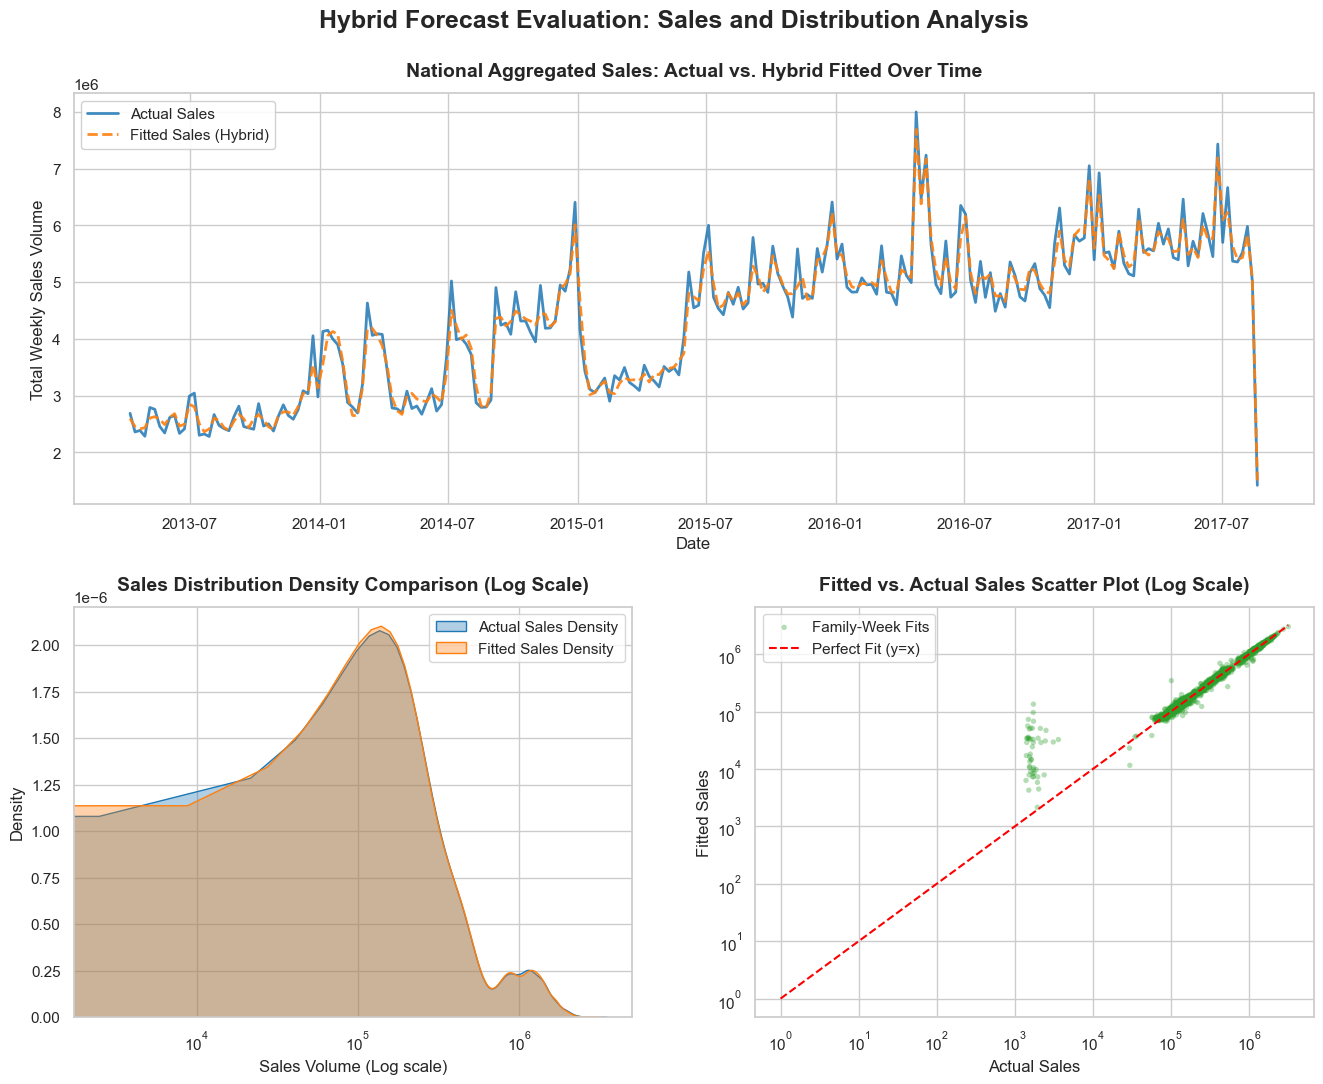

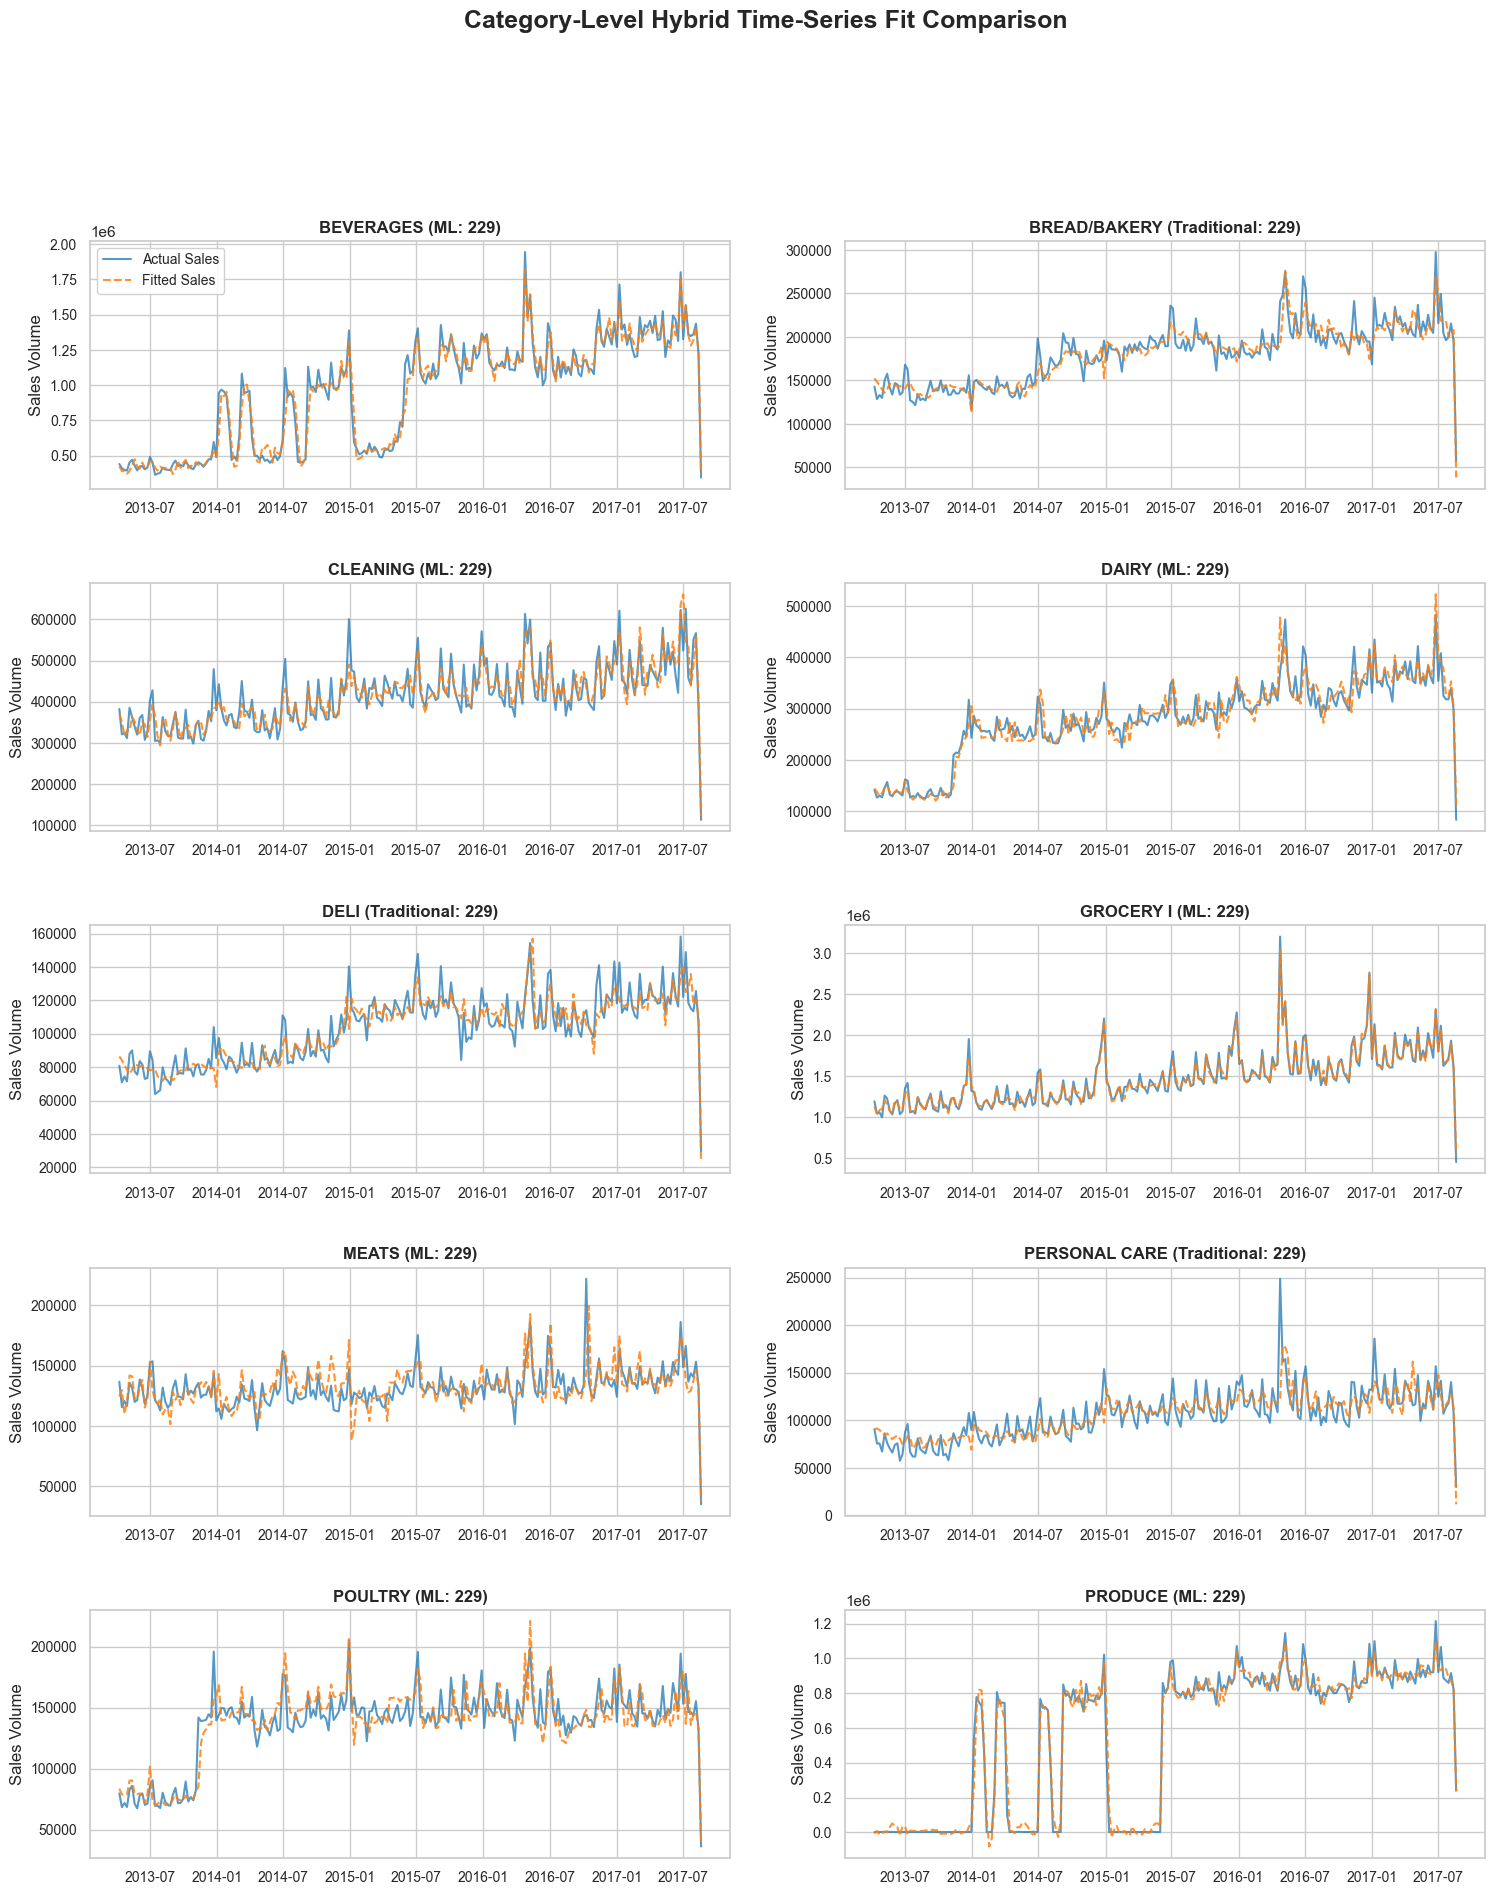

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# 1. ENVIRONMENT & DATA SAFING
# ===================================================================
if 'hybrid_fitted_values' not in locals() and 'hybrid_fitted_values' not in globals():
    try:
        csv_path = os.path.join(RESULT, 'hybrid_fitted_values.csv')
    except NameError:
        csv_path = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/hybrid_fitted_values.csv'
    hybrid_fitted_values = pd.read_csv(csv_path)

# Ensure 'date' is parsed as datetime for proper time-series rendering
hybrid_fitted_values['date'] = pd.to_datetime(hybrid_fitted_values['date'])

# Set up clean premium plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

# ===================================================================
# 2. OVERALL AGGREGATED SALES & DISTRIBUTION ANALYSIS (FIGURE 1)
# ===================================================================
# Aggregate actuals and fitted sales across all families per week
national_sales = hybrid_fitted_values.groupby('date')[['Actual_Sales', 'Fitted_Sales']].sum().reset_index()

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# Adjust spacing safely
fig.subplots_adjust(hspace=0.25, wspace=0.22)

# Panel 1: Aggregated Timeline (Spans full width)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(national_sales['date'], national_sales['Actual_Sales'], label='Actual Sales', color='#1f77b4', linewidth=2, alpha=0.85)
ax1.plot(national_sales['date'], national_sales['Fitted_Sales'], label='Fitted Sales (Hybrid)', color='#ff7f0e', linewidth=2, linestyle='--', alpha=0.9)
ax1.set_title('National Aggregated Sales: Actual vs. Hybrid Fitted Over Time', fontweight='bold', pad=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Weekly Sales Volume')
ax1.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# Panel 2: Density / KDE Comparison (Log scale)
ax2 = fig.add_subplot(gs[1, 0])
sns.kdeplot(data=hybrid_fitted_values, x='Actual_Sales', fill=True, color='#1f77b4', label='Actual Sales Density', ax=ax2, alpha=0.35)
sns.kdeplot(data=hybrid_fitted_values, x='Fitted_Sales', fill=True, color='#ff7f0e', label='Fitted Sales Density', ax=ax2, alpha=0.35)
ax2.set_xscale('log')
ax2.set_title('Sales Distribution Density Comparison (Log Scale)', fontweight='bold', pad=12)
ax2.set_xlabel('Sales Volume (Log scale)')
ax2.set_ylabel('Density')
ax2.legend(frameon=True, facecolor='white')

# Panel 3: Scatter Plot of Fitted vs. Actual Sales (Log Scale)
ax3 = fig.add_subplot(gs[1, 1])
# Draw a random sample of records for cleaner visualization (prevents overplotting)
sample_df = hybrid_fitted_values.sample(min(len(hybrid_fitted_values), 5000), random_state=42)
ax3.scatter(sample_df['Actual_Sales'], sample_df['Fitted_Sales'], color='#2ca02c', alpha=0.35, edgecolors='none', s=15, label='Family-Week Fits')

# Draw diagonal y=x helper line
max_val = max(hybrid_fitted_values['Actual_Sales'].max(), hybrid_fitted_values['Fitted_Sales'].max())
ax3.plot([1, max_val], [1, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect Fit (y=x)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title('Fitted vs. Actual Sales Scatter Plot (Log Scale)', fontweight='bold', pad=12)
ax3.set_xlabel('Actual Sales')
ax3.set_ylabel('Fitted Sales')
ax3.legend(frameon=True, facecolor='white')

# Save visual to results/dashboard_plots if directories exist
try:
    plot_save_path = os.path.join(RESULT, 'dashboard_plots', 'hybrid_overall_fitted_evaluation.png')
    plt.savefig(plot_save_path, bbox_inches='tight', dpi=150)
except Exception:
    pass

plt.suptitle('Hybrid Forecast Evaluation: Sales and Distribution Analysis', fontweight='bold', y=0.95)
plt.show()

# ===================================================================
# 3. CATEGORY-LEVEL FIT COMPARISON (FIGURE 2)
# ===================================================================
families = hybrid_fitted_values['family'].unique()
n_families = len(families)

# Set up grid subplots based on family count
n_rows = int(np.ceil(n_families / 2))
fig_fam, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.2 * n_rows))

# Adjust spacing safely
fig_fam.subplots_adjust(hspace=0.38, wspace=0.18)
axes = axes.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].sort_values('date')
    ax = axes[idx]
    
    ax.plot(fam_data['date'], fam_data['Actual_Sales'], label='Actual Sales', color='#1f77b4', linewidth=1.5, alpha=0.75)
    ax.plot(fam_data['date'], fam_data['Fitted_Sales'], label='Fitted Sales', color='#ff7f0e', linewidth=1.5, linestyle='--', alpha=0.85)
    
    # Identify which model route was chosen for this category (ML vs Traditional)
    model_counts = fam_data['model_used'].value_counts()
    model_str = ", ".join([f"{k}: {v}" for k, v in model_counts.items()])
    
    ax.set_title(f"{family} ({model_str})", fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Sales Volume')
    ax.tick_params(axis='both', which='major', labelsize=10)
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10)

# Delete empty grids if any remain
for idx in range(n_families, len(axes)):
    fig_fam.delaxes(axes[idx])

try:
    plot_save_path2 = os.path.join(RESULT, 'dashboard_plots', 'hybrid_family_fitted_evaluation.png')
    plt.savefig(plot_save_path2, bbox_inches='tight', dpi=150)
except Exception:
    pass

plt.suptitle('Category-Level Hybrid Time-Series Fit Comparison', fontweight='bold', y=0.99, fontsize=18)
plt.show()

                       RAW SALES NORMALITY METRICS BY PRODUCT FAMILY                       


,Family,Actual Skewness,Actual Excess Kurtosis,Actual Normality p-val,Actual Is Normal?,Fitted Skewness,Fitted Excess Kurtosis,Fitted Normality p-val,Fitted Is Normal?
0,BEVERAGES,-0.11,-1.20,2.43e-25,NO,-0.16,-1.30,5.59e-47,NO
1,BREAD/BAKERY,0.05,0.60,2.04e-01,YES,-0.32,0.88,1.07e-02,NO
2,CLEANING,0.33,1.08,4.15e-03,NO,0.29,1.67,6.32e-04,NO
3,DAIRY,-0.48,0.21,1.04e-02,NO,-0.41,0.03,4.11e-02,NO
4,DELI,-0.05,0.03,8.96e-01,YES,-0.37,0.44,2.71e-02,NO
5,GROCERY I,1.15,3.29,1.15e-13,NO,1.12,2.95,7.34e-13,NO
6,MEATS,0.48,10.37,3.44e-14,NO,-0.05,6.85,9.47e-10,NO
7,PERSONAL CARE,0.83,3.48,8.75e-11,NO,-0.01,1.40,9.46e-03,NO
8,POULTRY,-1.11,1.30,4.46e-10,NO,-0.99,1.17,1.29e-08,NO
9,PRODUCE,-0.46,-1.61,0.00e+00,NO,-0.50,-1.61,0.00e+00,NO


[SUCCESS] Saved Distribution Plot to: /Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/dashboard_plots/hybrid_family_densities_normality.png


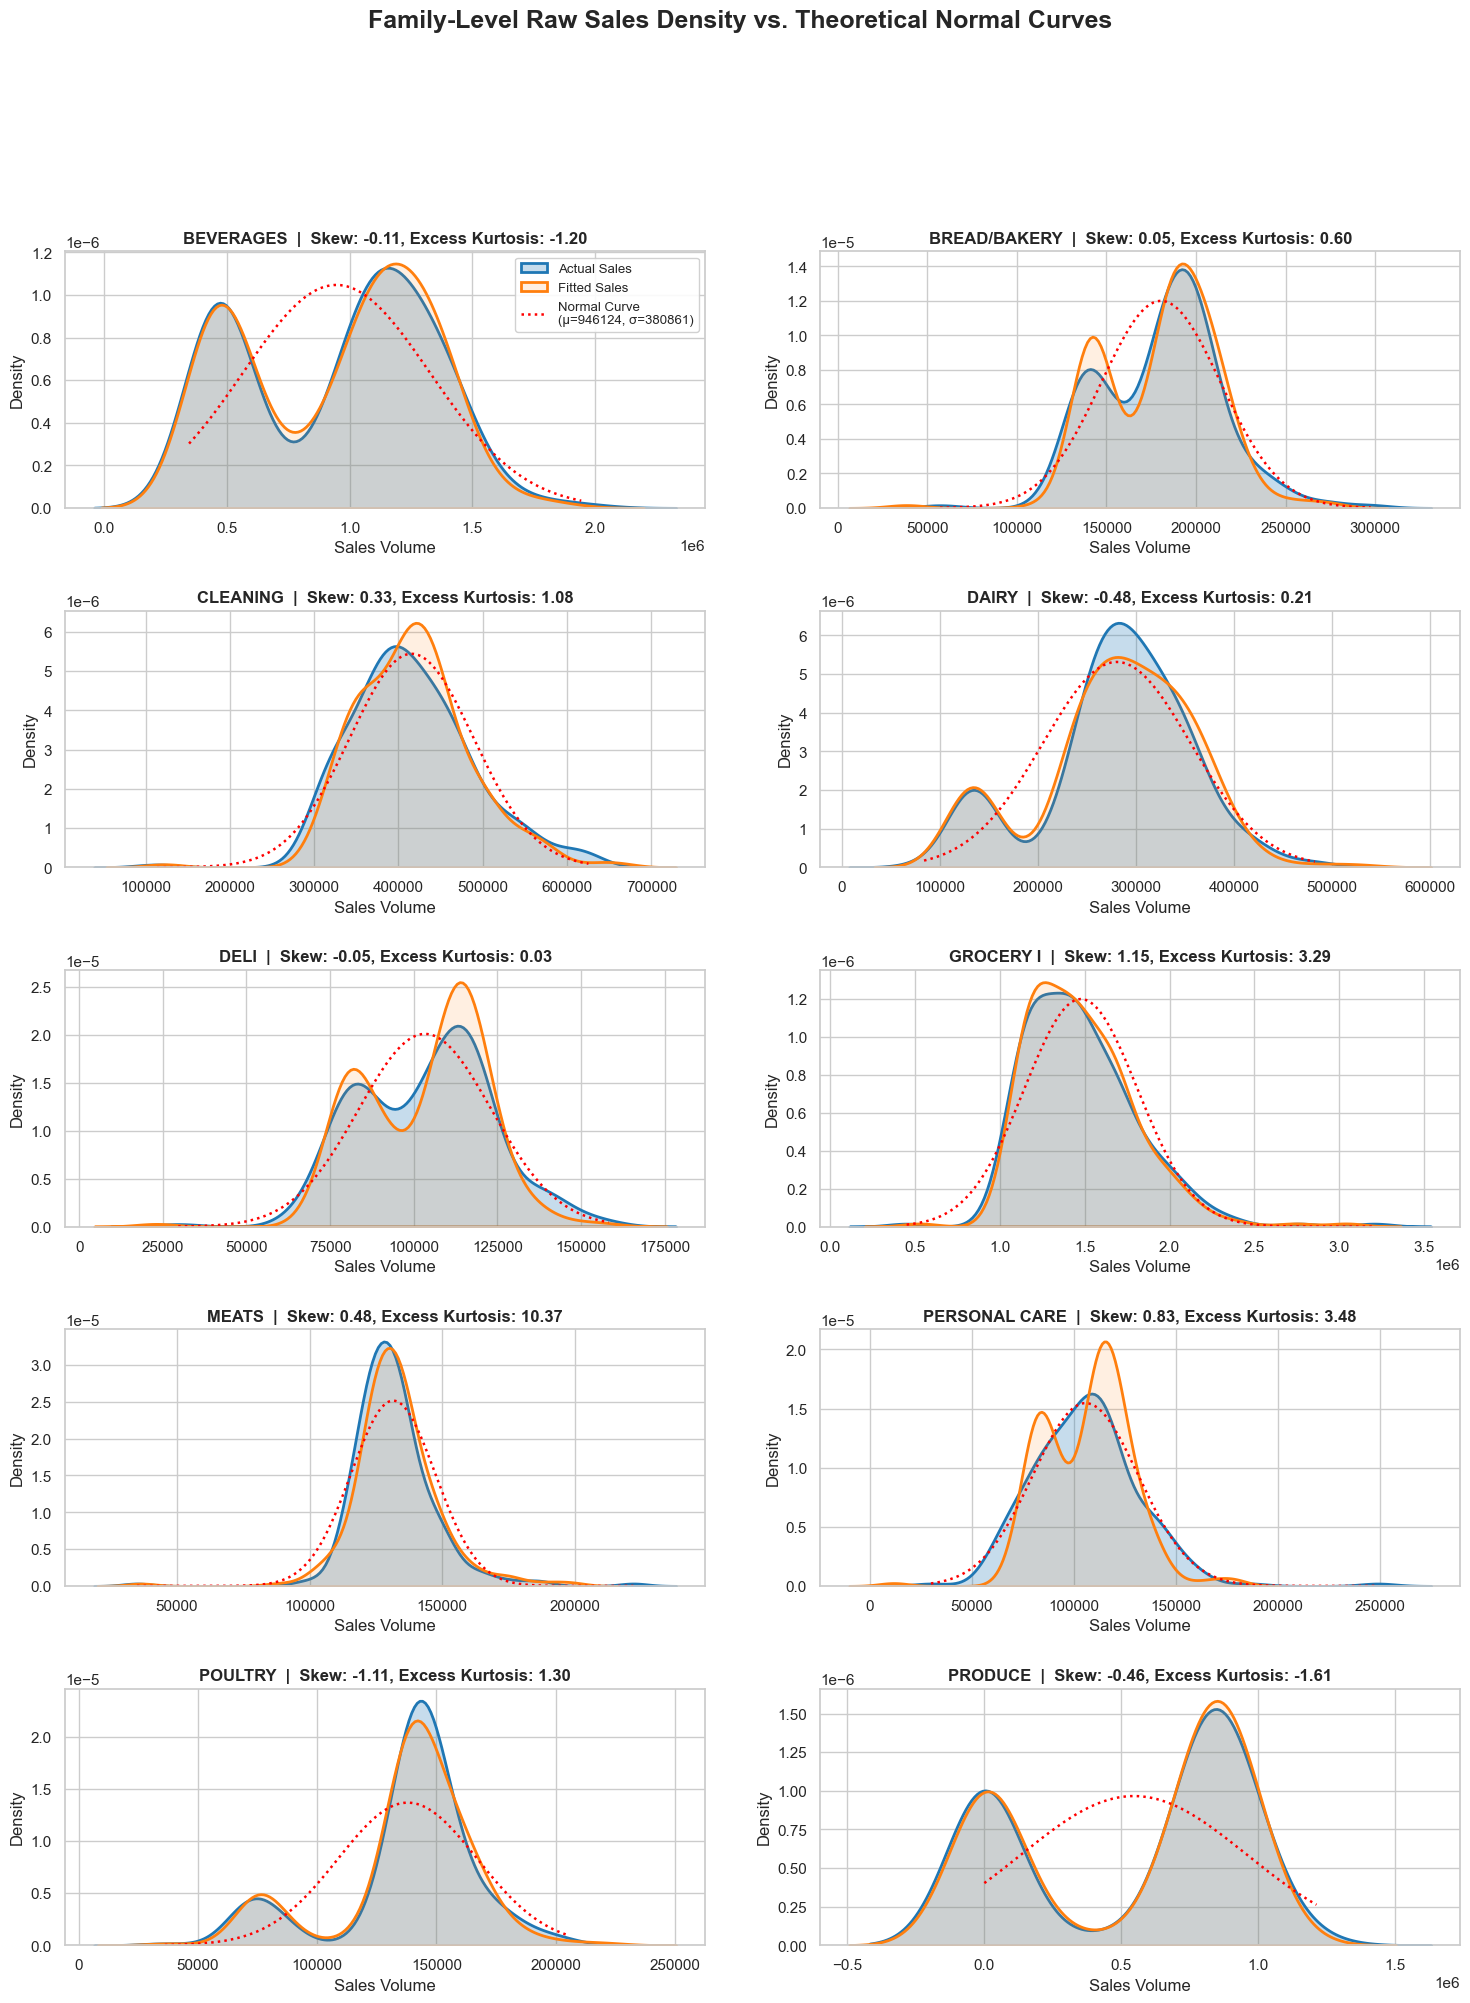

[SUCCESS] Saved Q-Q Plot to: /Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/dashboard_plots/hybrid_family_qq_normality.png


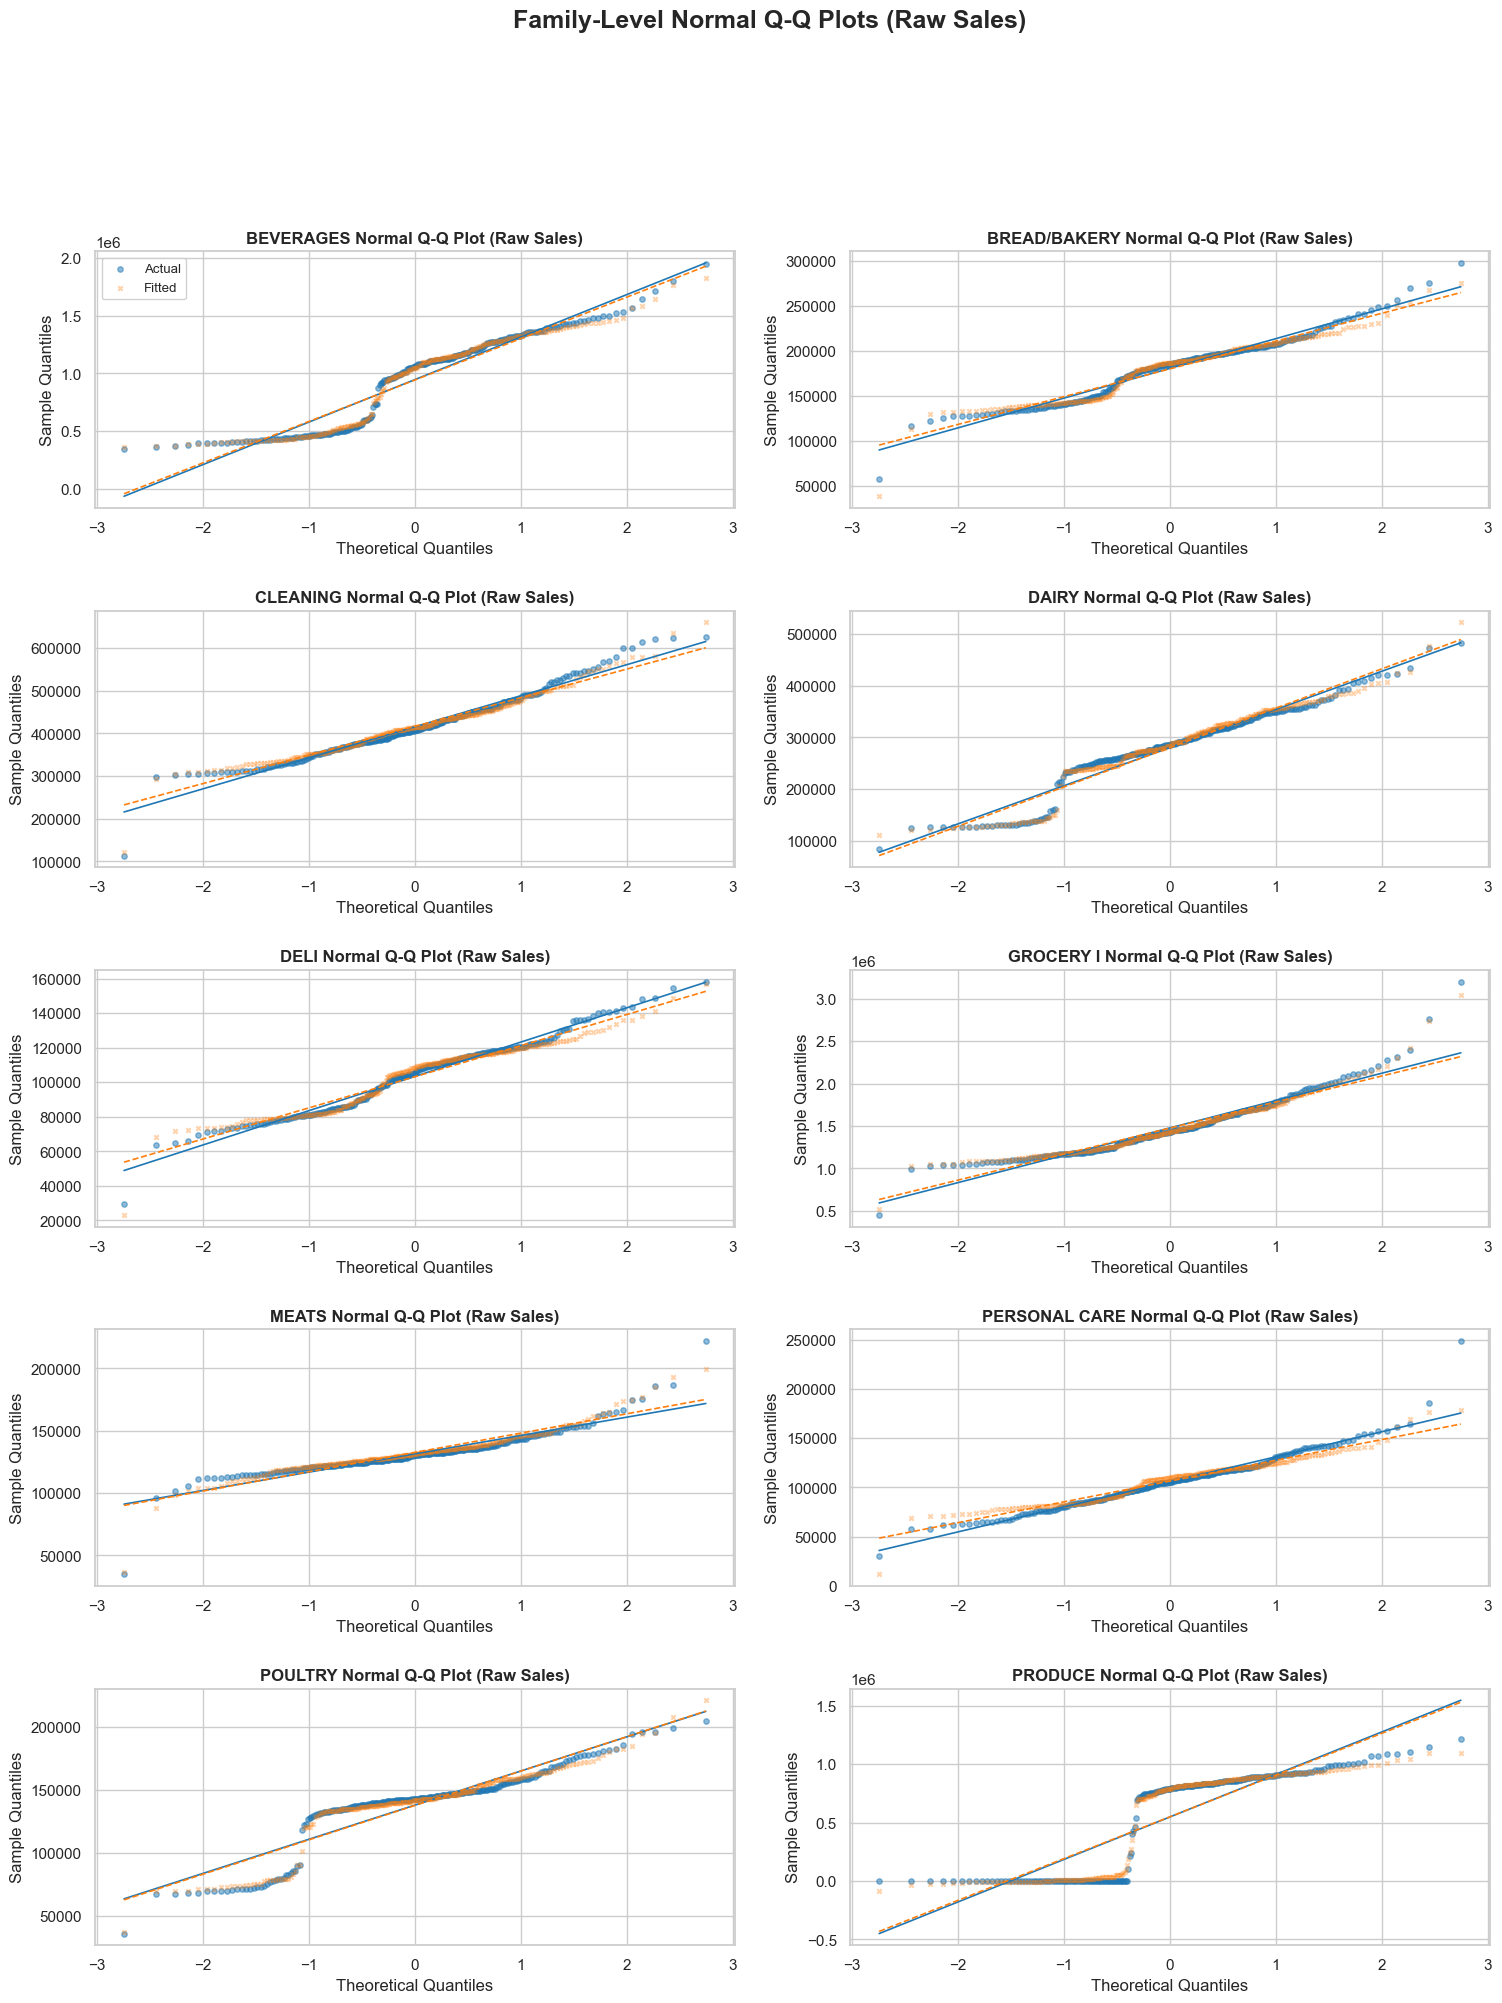

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ===================================================================
# 1. ENVIRONMENT & DATA LOAD CHECK
# ===================================================================
if 'hybrid_fitted_values' not in locals() and 'hybrid_fitted_values' not in globals():
    try:
        csv_path = os.path.join(RESULT, 'hybrid_fitted_values.csv')
    except NameError:
        csv_path = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/hybrid_fitted_values.csv'
    hybrid_fitted_values = pd.read_csv(csv_path)

# Ensure 'date' is parsed as datetime
hybrid_fitted_values['date'] = pd.to_datetime(hybrid_fitted_values['date'])

# Extract unique families
families = hybrid_fitted_values['family'].unique()
n_families = len(families)

# Create save directory fallback path in case RESULT is not defined
try:
    save_dir = os.path.join(RESULT, 'dashboard_plots')
except NameError:
    save_dir = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/dashboard_plots'
os.makedirs(save_dir, exist_ok=True)

# ===================================================================
# 2. TABULAR STATISTICAL NORMALITY METRICS BY FAMILY
# ===================================================================
normality_summary = []
for family in families:
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    
    # Compute metrics for Actuals (D'Agostino requires at least 8 samples)
    _, p_act = stats.normaltest(act) if len(act) >= 8 else (0, 0)
    skew_act = stats.skew(act)
    kurt_act = stats.kurtosis(act)
    
    # Compute metrics for Fitted
    _, p_fit = stats.normaltest(fit) if len(fit) >= 8 else (0, 0)
    skew_fit = stats.skew(fit)
    kurt_fit = stats.kurtosis(fit)
    
    normality_summary.append({
        'Family': family,
        'Actual Skewness': round(skew_act, 2),
        'Actual Excess Kurtosis': round(kurt_act, 2),
        'Actual Normality p-val': f"{p_act:.2e}",
        'Actual Is Normal?': 'YES' if p_act >= 0.05 else 'NO',
        'Fitted Skewness': round(skew_fit, 2),
        'Fitted Excess Kurtosis': round(kurt_fit, 2),
        'Fitted Normality p-val': f"{p_fit:.2e}",
        'Fitted Is Normal?': 'YES' if p_fit >= 0.05 else 'NO'
    })

summary_df = pd.DataFrame(normality_summary)
print("=" * 105)
print("                       RAW SALES NORMALITY METRICS BY PRODUCT FAMILY                       ")
print("=" * 105)
display(summary_df)
print("=" * 105)

# Setup layout configurations for 10 subplots (5 rows x 2 cols)
n_rows = int(np.ceil(n_families / 2))
sns.set_theme(style="whitegrid")

# ===================================================================
# 3. VISUAL 1: SALES DENSITY PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_dist, axes_dist = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_dist.subplots_adjust(hspace=0.4, wspace=0.18)
axes_dist = axes_dist.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    ax = axes_dist[idx]
    
    # Plot Actual and Fitted KDEs
    sns.kdeplot(act, ax=ax, color='#1f77b4', linewidth=2, fill=True, alpha=0.25, label='Actual Sales')
    sns.kdeplot(fit, ax=ax, color='#ff7f0e', linewidth=2, fill=True, alpha=0.12, label='Fitted Sales')
    
    # Overlay Theoretical Normal distribution matching that family's actual parameters
    mean_fam, std_fam = np.mean(act), np.std(act)
    x_vals = np.linspace(min(act), max(act), 1000)
    normal_curve = stats.norm.pdf(x_vals, mean_fam, std_fam)
    ax.plot(x_vals, normal_curve, color='red', linestyle=':', linewidth=1.8, 
            label=f'Normal Curve\n(μ={mean_fam:.0f}, σ={std_fam:.0f})')
    
    # Family headers displaying skewness and kurtosis
    ax.set_title(f"{family}  |  Skew: {stats.skew(act):.2f}, Excess Kurtosis: {stats.kurtosis(act):.2f}", fontweight='bold', fontsize=12)
    ax.set_xlabel('Sales Volume')
    ax.set_ylabel('Density')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_dist)):
    fig_dist.delaxes(axes_dist[idx])

plt.suptitle('Family-Level Raw Sales Density vs. Theoretical Normal Curves', fontweight='bold', y=0.99, fontsize=18)

# Save distribution plot
try:
    plot_save_path1 = os.path.join(save_dir, 'hybrid_family_densities_normality.png')
    fig_dist.savefig(plot_save_path1, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Distribution Plot to: {plot_save_path1}")
except Exception as e:
    print(f"[WARNING] Could not save distribution plot: {e}")

plt.show()

# ===================================================================
# 4. VISUAL 2: NORMAL Q-Q PLOTS BY FAMILY & SAVE (5x2 GRID)
# ===================================================================
fig_qq, axes_qq = plt.subplots(nrows=n_rows, ncols=2, figsize=(18, 4.4 * n_rows))
fig_qq.subplots_adjust(hspace=0.4, wspace=0.18)
axes_qq = axes_qq.flatten()

for idx, family in enumerate(families):
    fam_data = hybrid_fitted_values[hybrid_fitted_values['family'] == family].dropna()
    act = fam_data['Actual_Sales'].values
    fit = fam_data['Fitted_Sales'].values
    ax = axes_qq[idx]
    
    # Theoretical normal Q-Q plot for Actuals
    (osm_act, osr_act), (slope_act, intercept_act, r_act) = stats.probplot(act, dist="norm")
    ax.scatter(osm_act, osr_act, color='#1f77b4', alpha=0.5, s=15, label='Actual')
    ax.plot(osm_act, slope_act*osm_act + intercept_act, color='#1f77b4', linestyle='-', linewidth=1.2)
    
    # Theoretical normal Q-Q plot for Fitted
    (osm_fit, osr_fit), (slope_fit, intercept_fit, r_fit) = stats.probplot(fit, dist="norm")
    ax.scatter(osm_fit, osr_fit, color='#ff7f0e', alpha=0.35, s=10, marker='x', label='Fitted')
    ax.plot(osm_fit, slope_fit*osm_fit + intercept_fit, color='#ff7f0e', linestyle='--', linewidth=1.2)
    
    ax.set_title(f"{family} Normal Q-Q Plot (Raw Sales)", fontweight='bold', fontsize=12)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    if idx == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)

# Hide any unused axis plots
for idx in range(n_families, len(axes_qq)):
    fig_qq.delaxes(axes_qq[idx])

plt.suptitle('Family-Level Normal Q-Q Plots (Raw Sales)', fontweight='bold', y=0.99, fontsize=18)

# Save Q-Q plot
try:
    plot_save_path2 = os.path.join(save_dir, 'hybrid_family_qq_normality.png')
    fig_qq.savefig(plot_save_path2, bbox_inches='tight', dpi=150)
    print(f"[SUCCESS] Saved Q-Q Plot to: {plot_save_path2}")
except Exception as e:
    print(f"[WARNING] Could not save Q-Q plot: {e}")

plt.show()